# B17 — GSS 2024 preprocessing (M1 → M2 → item split)

Everything before the first LLM call: harmonised microdata, an interpretable
cluster tree, per-cluster ground-truth histograms, and the anchor/target split
that §5.1 of the architecture spec calls for.

**Data.** GSS 2024 cross-section, Release 3 (NORC, March 2026). The spec names
GSS 2022 as the primary bed but §5.6 says to swap in a newer wave if one exists
— it does, and the newer wave is the better choice on leakage grounds (F6).

**What to look at first.** Figures 1, 2 and 9. They show a constraint the spec
does not account for: at the K the spec asks for, almost no (cluster × item)
cell clears the n_eff ≥ 30 gate that §5.2 imposes on scoring.

---

## Pipeline

| Module | Output | Spec |
|---|---|---|
| M1 ingest/harmonise | `individual_table.parquet`, `item_codebook.yaml` | §3.3 M1 |
| M2 cluster tree | `cluster_tree.json`, `cluster_stats.parquet` | §3.3 M2 |
| — level-0 marginals | `population_stats.parquet` | §5.4 B0a |
| item split | `item_split.csv` | §5.1 |
| K sweep | `k_sweep.csv` | §5.5 / §5.7 |

## 0 · Setup

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd, yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
from popsim.report import plots
plots.use_style()

CFG = ROOT / "configs" / "gss_main.yaml"
cfg = yaml.safe_load(CFG.read_text())
RUN = ROOT / cfg["output"]["dir"]
print("run dir:", RUN)

run dir: /home/claude/popsim/runs/gss2024_main


### Re-run the pipeline from scratch

Takes about 10 seconds. Skip it if `runs/gss2024_main/` is already populated.

In [2]:
# import run_pipeline; run_pipeline.main(str(CFG))

In [3]:
table   = pd.read_parquet(RUN / "individual_table.parquet")
cstats  = pd.read_parquet(RUN / "cluster_stats.parquet")
cstats_c= pd.read_parquet(RUN / "cluster_stats_coarse.parquet")
pstats  = pd.read_parquet(RUN / "population_stats.parquet")
split   = pd.read_csv(RUN / "item_split.csv")
sweep   = pd.read_csv(RUN / "k_sweep.csv")
nodes   = json.loads((RUN / "cluster_tree.json").read_text())
nodes_c = json.loads((RUN / "cluster_tree_coarse.json").read_text())
manifest= json.loads((RUN / "manifest.json").read_text())
codebook= {c["item_id"]: c for c in yaml.safe_load((RUN / "item_codebook.yaml").read_text())}
topic_of= {k: v["topic"] for k, v in codebook.items()}

MIN_NEFF = cfg["scoring"]["min_neff"]
K, K_C   = manifest["K"], manifest["K_coarse"]
MIN_CELL = manifest["min_cell"]
print(f"{len(table):,} respondents · {len(codebook)} items · K = {K} (coarse {K_C})")

3,309 respondents · 507 items · K = 122 (coarse 26)


## 1 · M1 — did the harmonisation do what it claims?

In [4]:
for line in manifest["log"][:6]:
    print(line)
print()
print("contract checks:")
for k, v in manifest["checks"].items():
    flag = "" if v in (True, 0) or isinstance(v, int) else "   <-- FAILED"
    print(f"  {k:32s} {v}{flag}")

M1: weight variable = wtssnrps (Person post-stratification weight, nonrespondents adjusted)
M1: analytic sample = 3309 of 3986 rows (677 dropped for null/zero wtssnrps)
M1: items retained = 646 of 989 variables
M1: taxonomy retains 507 attitudinal/behavioral items (139 dropped as background/admin/quiz)
M2: merge-distance profile items = ['confinan', 'fear', 'satfin', 'nateduc', 'natchld', 'health', 'letin1a', 'compuse', 'hunt', 'polintrst', 'discaff', 'pray']
M2: min_cell search [(60, 37), (50, 46), (40, 57), (34, 65), (28, 74), (24, 84), (20, 99), (17, 122)] -> chose min_cell=17 for target_k=[100, 200]

contract checks:
  histograms_sum_to_1              True
  n_populated_cells                61789
  all_leaves_meet_min_cell         True
  n_leaves_below_min_cell          0
  leaf_ids_unique                  True
  weights_all_positive             True
  leaf_pop_share_sums_to_1         True
  no_item_in_both_roles            True
  every_respondent_assigned        True


In [5]:
# Harmonised demographics, weighted vs unweighted
demo_cols = [c for c in table.columns if c.startswith("demo_")]
rows = []
for c in demo_cols:
    m = table[c].notna()
    rows.append({"field": c.replace("demo_", ""), "levels": table[c].nunique(),
                 "missing": int((~m).sum()),
                 "missing_pct": round(100 * (~m).mean(), 1)})
pd.DataFrame(rows).sort_values("missing_pct", ascending=False)

,field,levels,missing,missing_pct
3,income_band,5,378,11.4
0,age_band,6,101,3.1
8,race,3,65,2.0
7,religion,13,40,1.2
1,sex,2,19,0.6
10,marital,5,15,0.5
9,employment,8,10,0.3
2,education,4,3,0.1
6,region,4,0,0.0
4,srcbelt,6,0,0.0


Income is the binding constraint: `CONINC` non-response puts >10% of
respondents outside any income-conditioned cell. They are **not** dropped —
they land in an explicit `unclassified` leaf, so population marginals stay
unbiased.

## 2 · M2 — the cluster tree

In [6]:
leaves = [n for n in nodes if n["level"] == 2]
print("level-1 nodes")
for n in [x for x in nodes if x["level"] == 1]:
    print(f"   n={n['n_raw']:5d}   {n['definition_text']}")

print(f"\n{len(leaves)} leaves — 8 largest")
for n in sorted(leaves, key=lambda x: -x["n_raw"])[:8]:
    print(f"   n={n['n_raw']:4d}  n_eff={n['n_eff']:6.1f}  share={n['pop_share']:.3f}")
    print(f"        {n['definition_text']}")

level-1 nodes
   n=  130   rural, the Midwest
   n=  682   urban/suburban, the Midwest
   n=   61   rural, the Northeast
   n=  480   urban/suburban, the Northeast
   n=   96   rural, the South
   n= 1214   urban/suburban, the South
   n=  646   urban or rural, the West

122 leaves — 8 largest
   n= 160  n_eff=  86.9  share=0.048
        urban/suburban, the South, [missing >=1 level-2 partition axis]
   n= 100  n_eff=  53.4  share=0.045
        urban or rural, the West, [missing >=1 level-2 partition axis]
   n=  72  n_eff=  21.2  share=0.020
        urban/suburban, the Midwest, [missing >=1 level-2 partition axis]
   n=  58  n_eff=  34.5  share=0.020
        urban/suburban, the Northeast, [missing >=1 level-2 partition axis]
   n=  51  n_eff=  29.4  share=0.021
        either sex, aged 18-24, any education level, bottom income quintile, urban/suburban, the South
   n=  49  n_eff=  23.7  share=0.016
        either sex, aged 55-64, some college to college+, any income, urban/suburban, t

Every leaf definition is a literal conjunction of demographic constraints, so
the stat card in M3 can be generated rather than authored — that is the whole
reason for rejecting embedding clustering in §2.2.

## 3 · Figures

In [7]:
from IPython.display import Image, display
FIG = ROOT / cfg["output"]["figures"]

def show(name, note=""):
    if note: print(note)
    display(Image(filename=str(FIG / name)))

### 3.1 The binding constraint

The spec asks for K ≈ 150 (§1.4, §2.2) *and* excludes any cell below
n_eff = 30 from scoring (§5.2). On a 3,309-respondent sample those two
requirements are close to mutually exclusive.

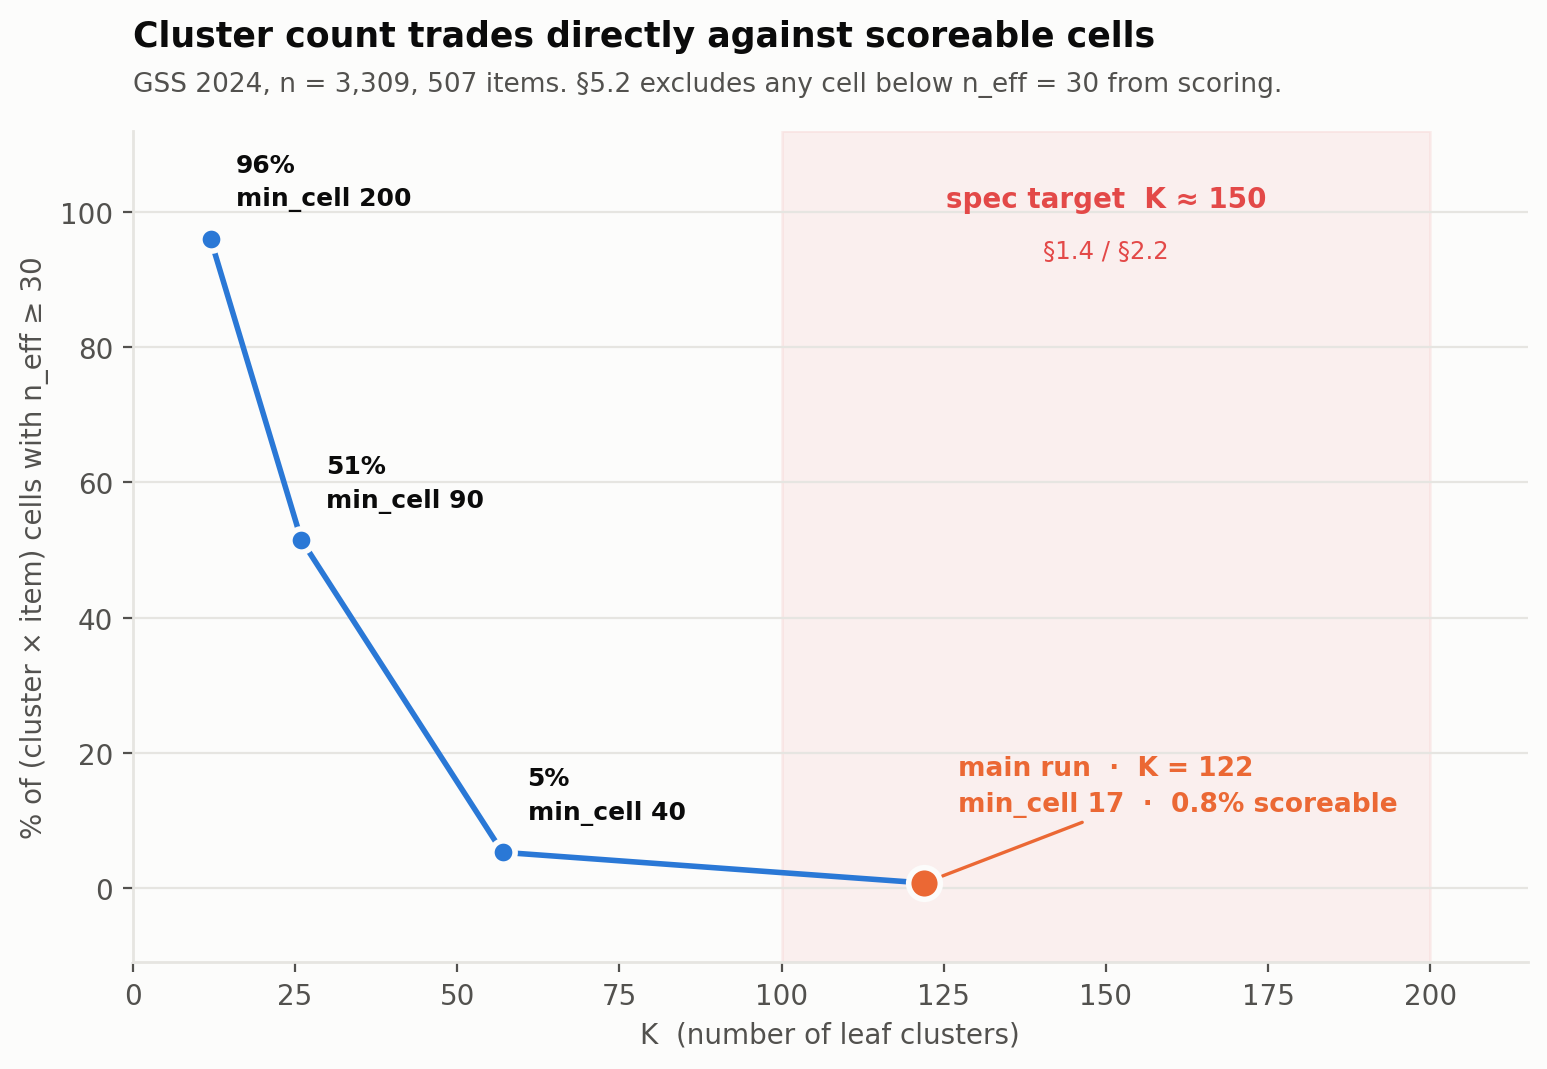

In [8]:
show("fig01_k_vs_scoreable.png")

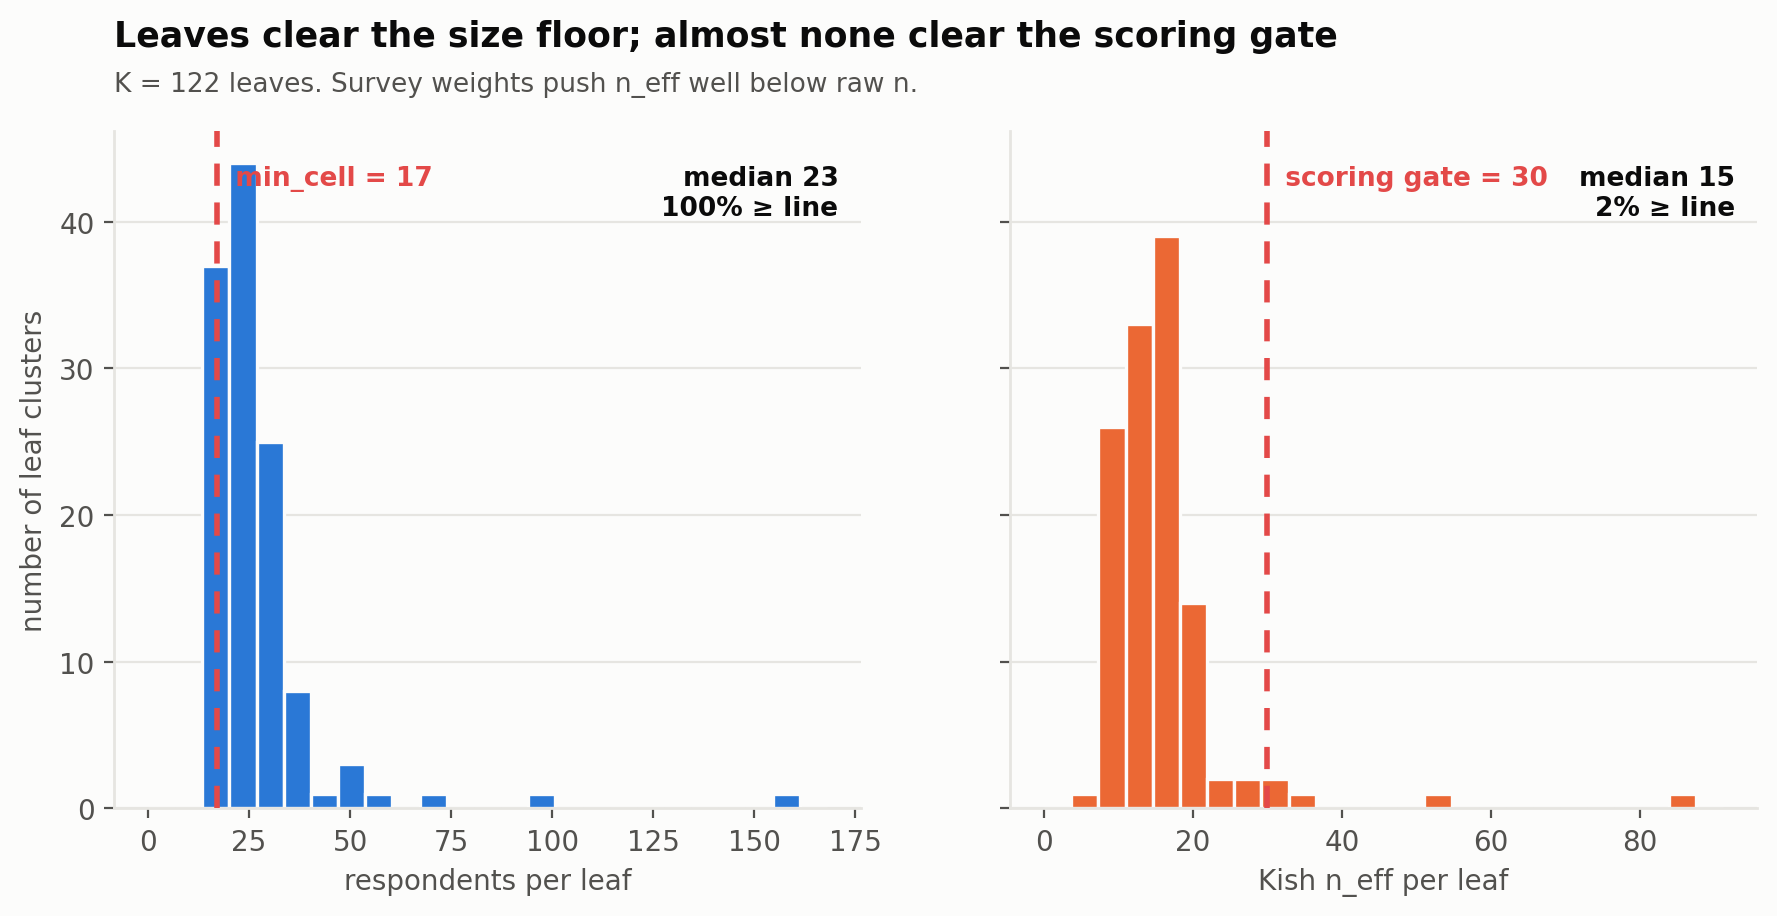

In [9]:
show("fig02_leaf_sizes.png")

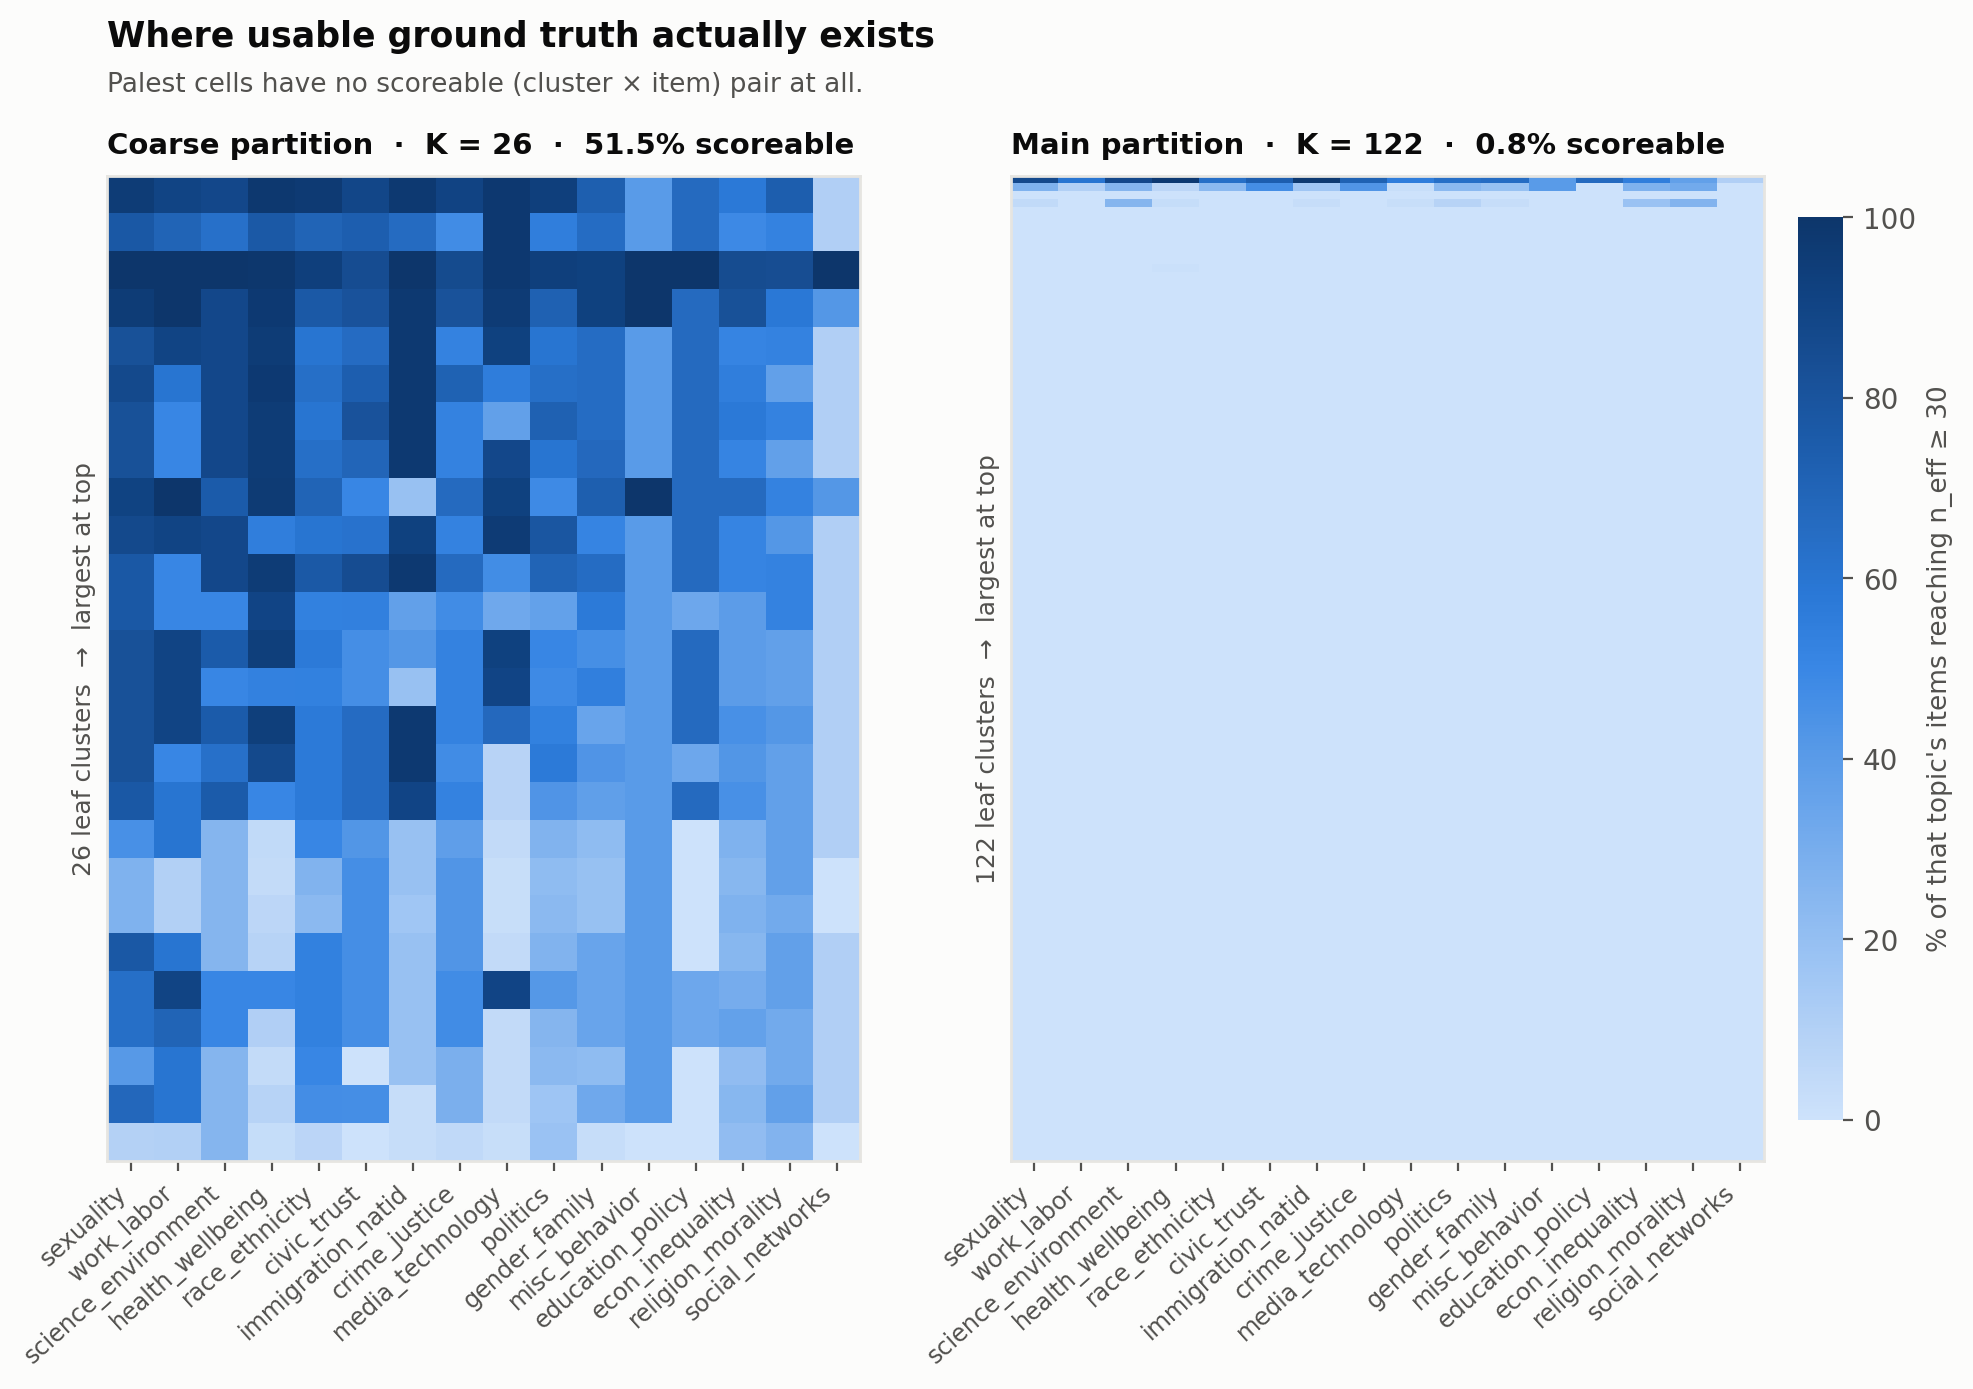

In [10]:
show("fig09_availability.png")

### 3.2 Item heterogeneity

§1.4 claim (i) is scored on the *top-quartile heterogeneity* items. Which items
those are depends entirely on whether heterogeneity is debiased first.

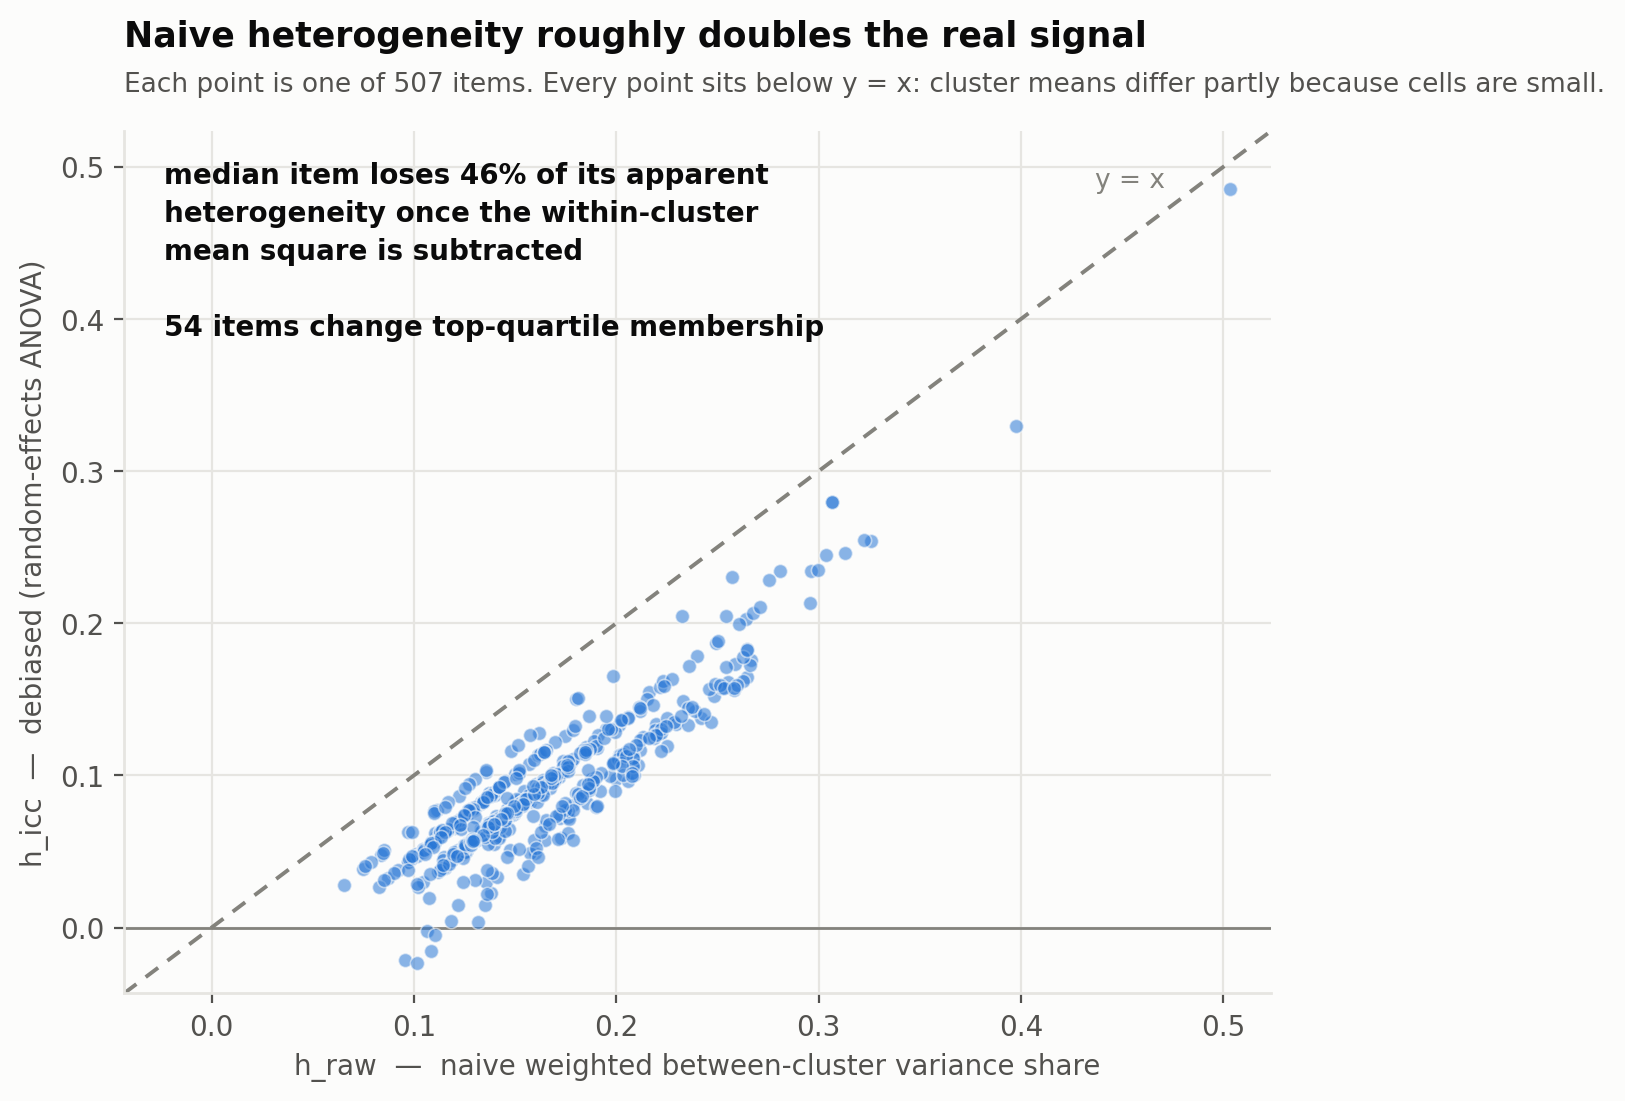

In [11]:
show("fig03_heterogeneity_bias.png")

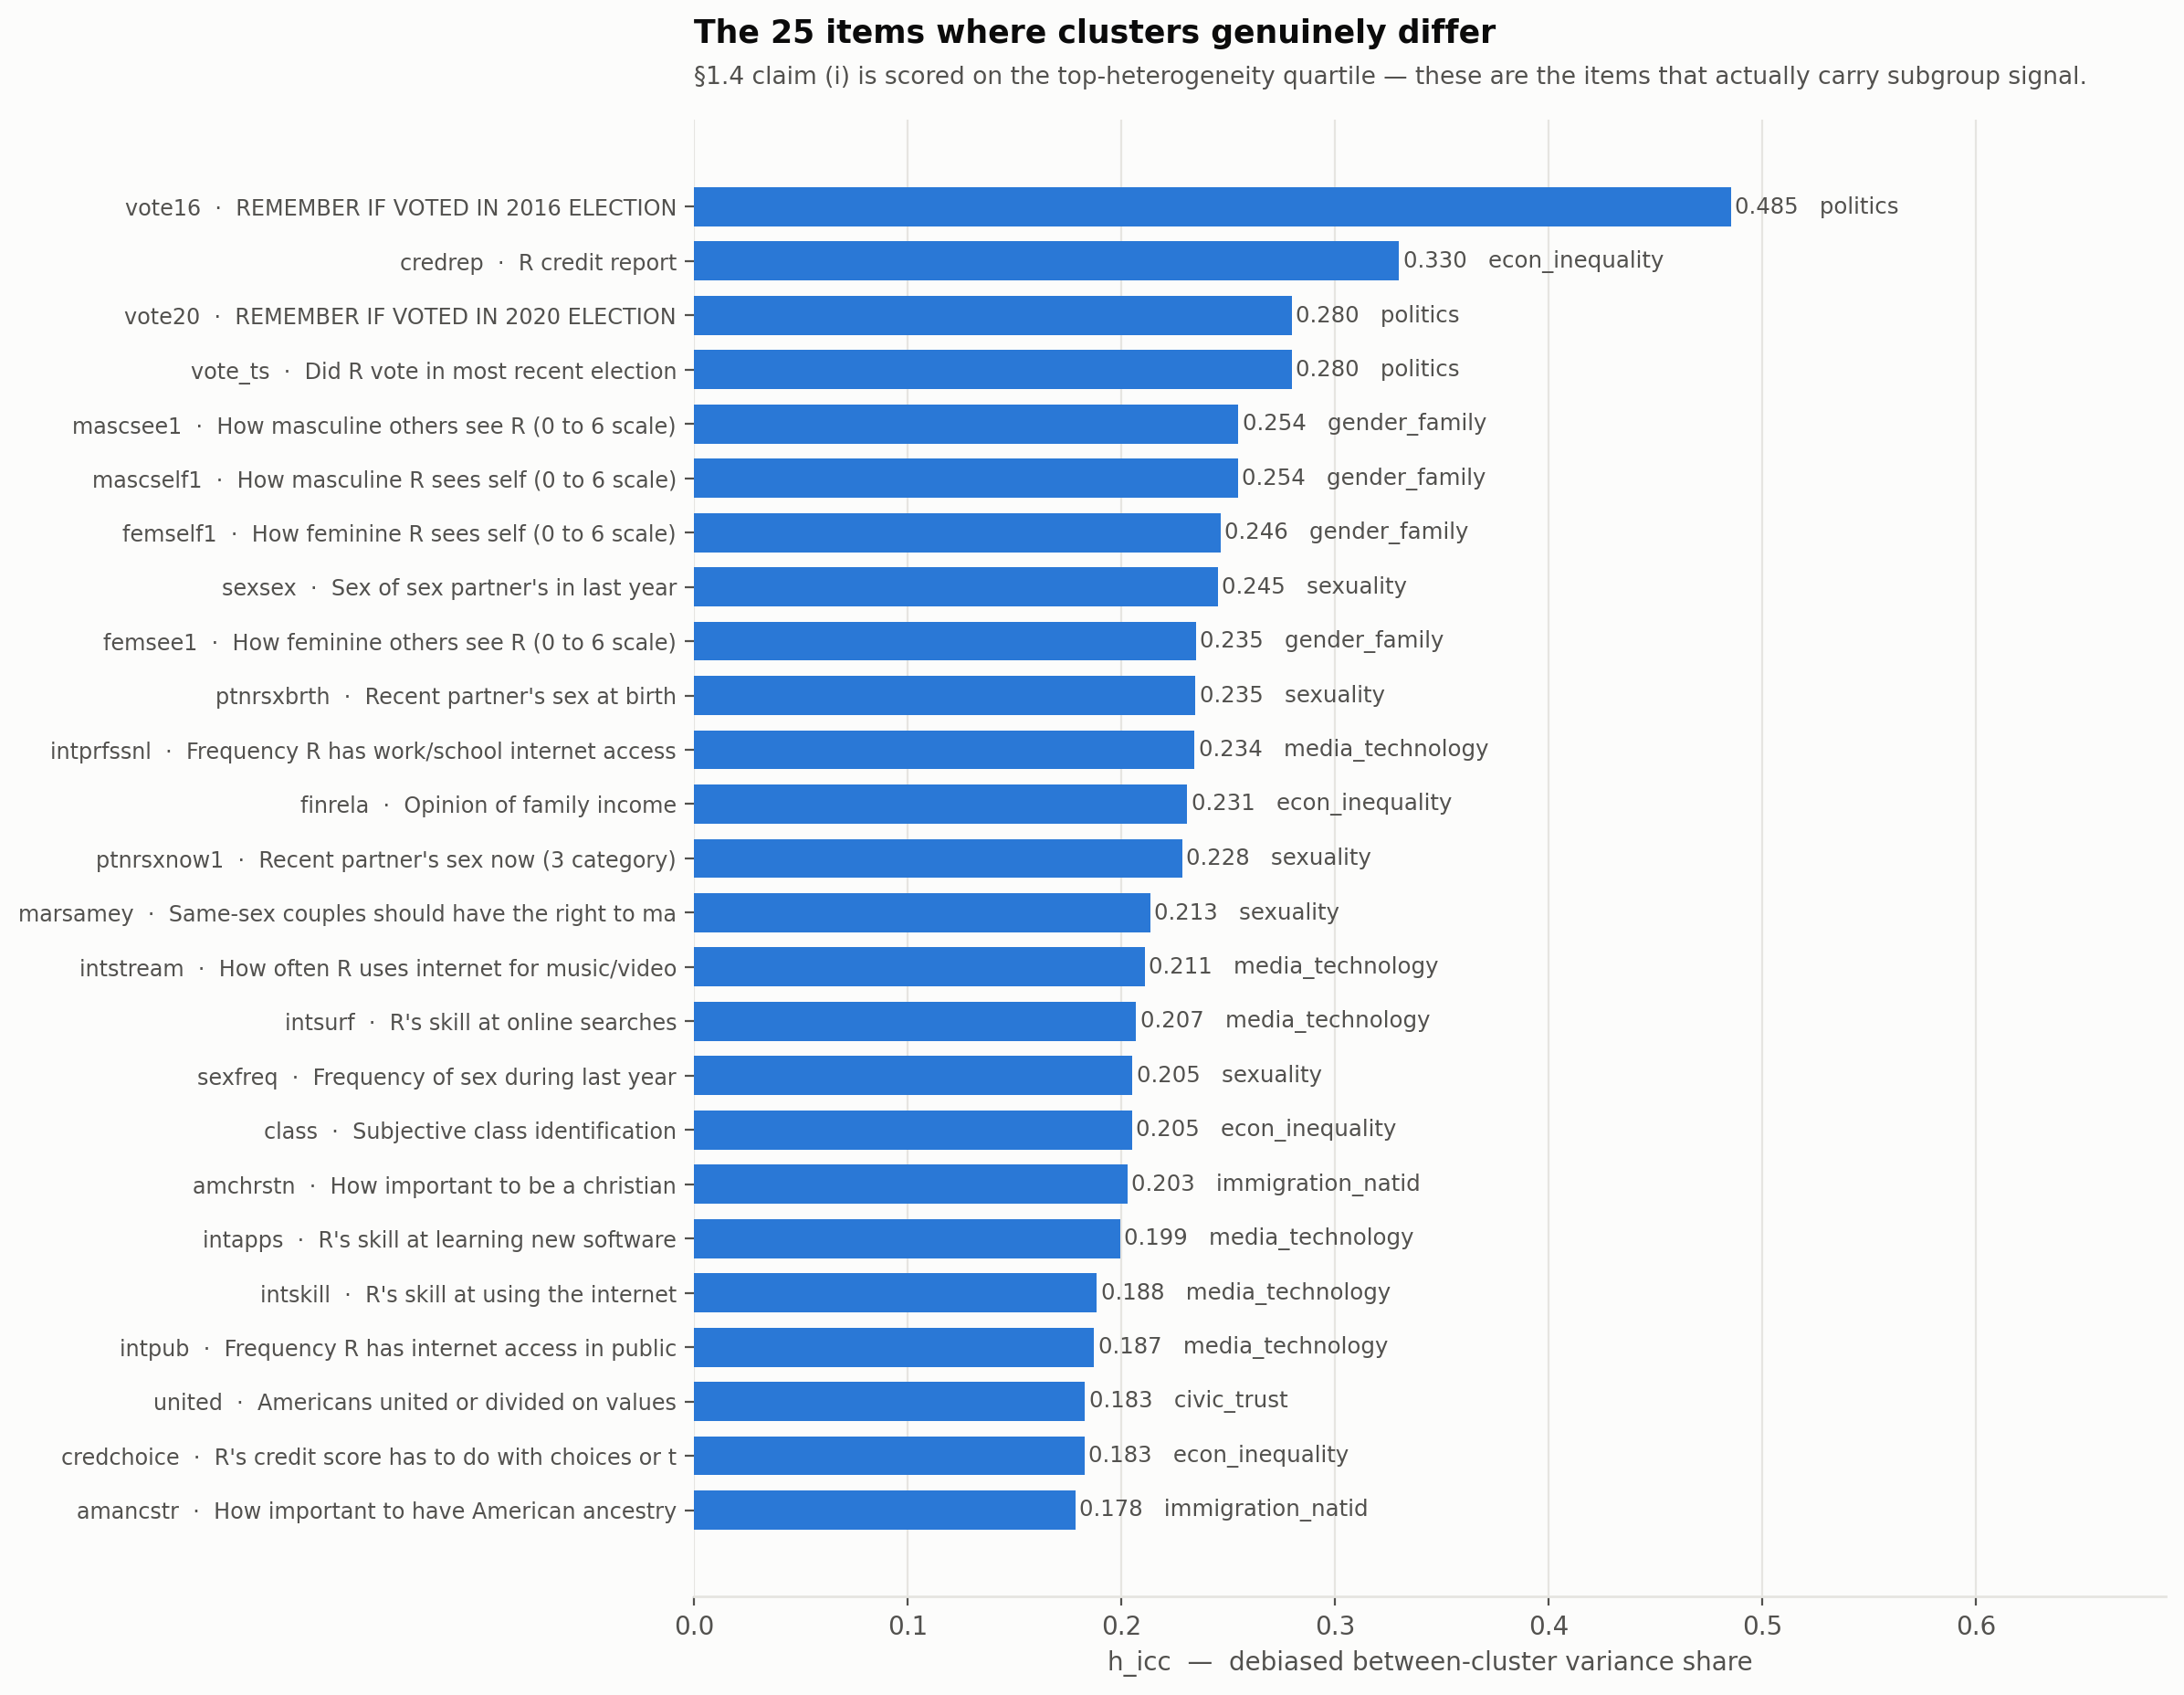

In [12]:
show("fig04_top_heterogeneity_items.png")

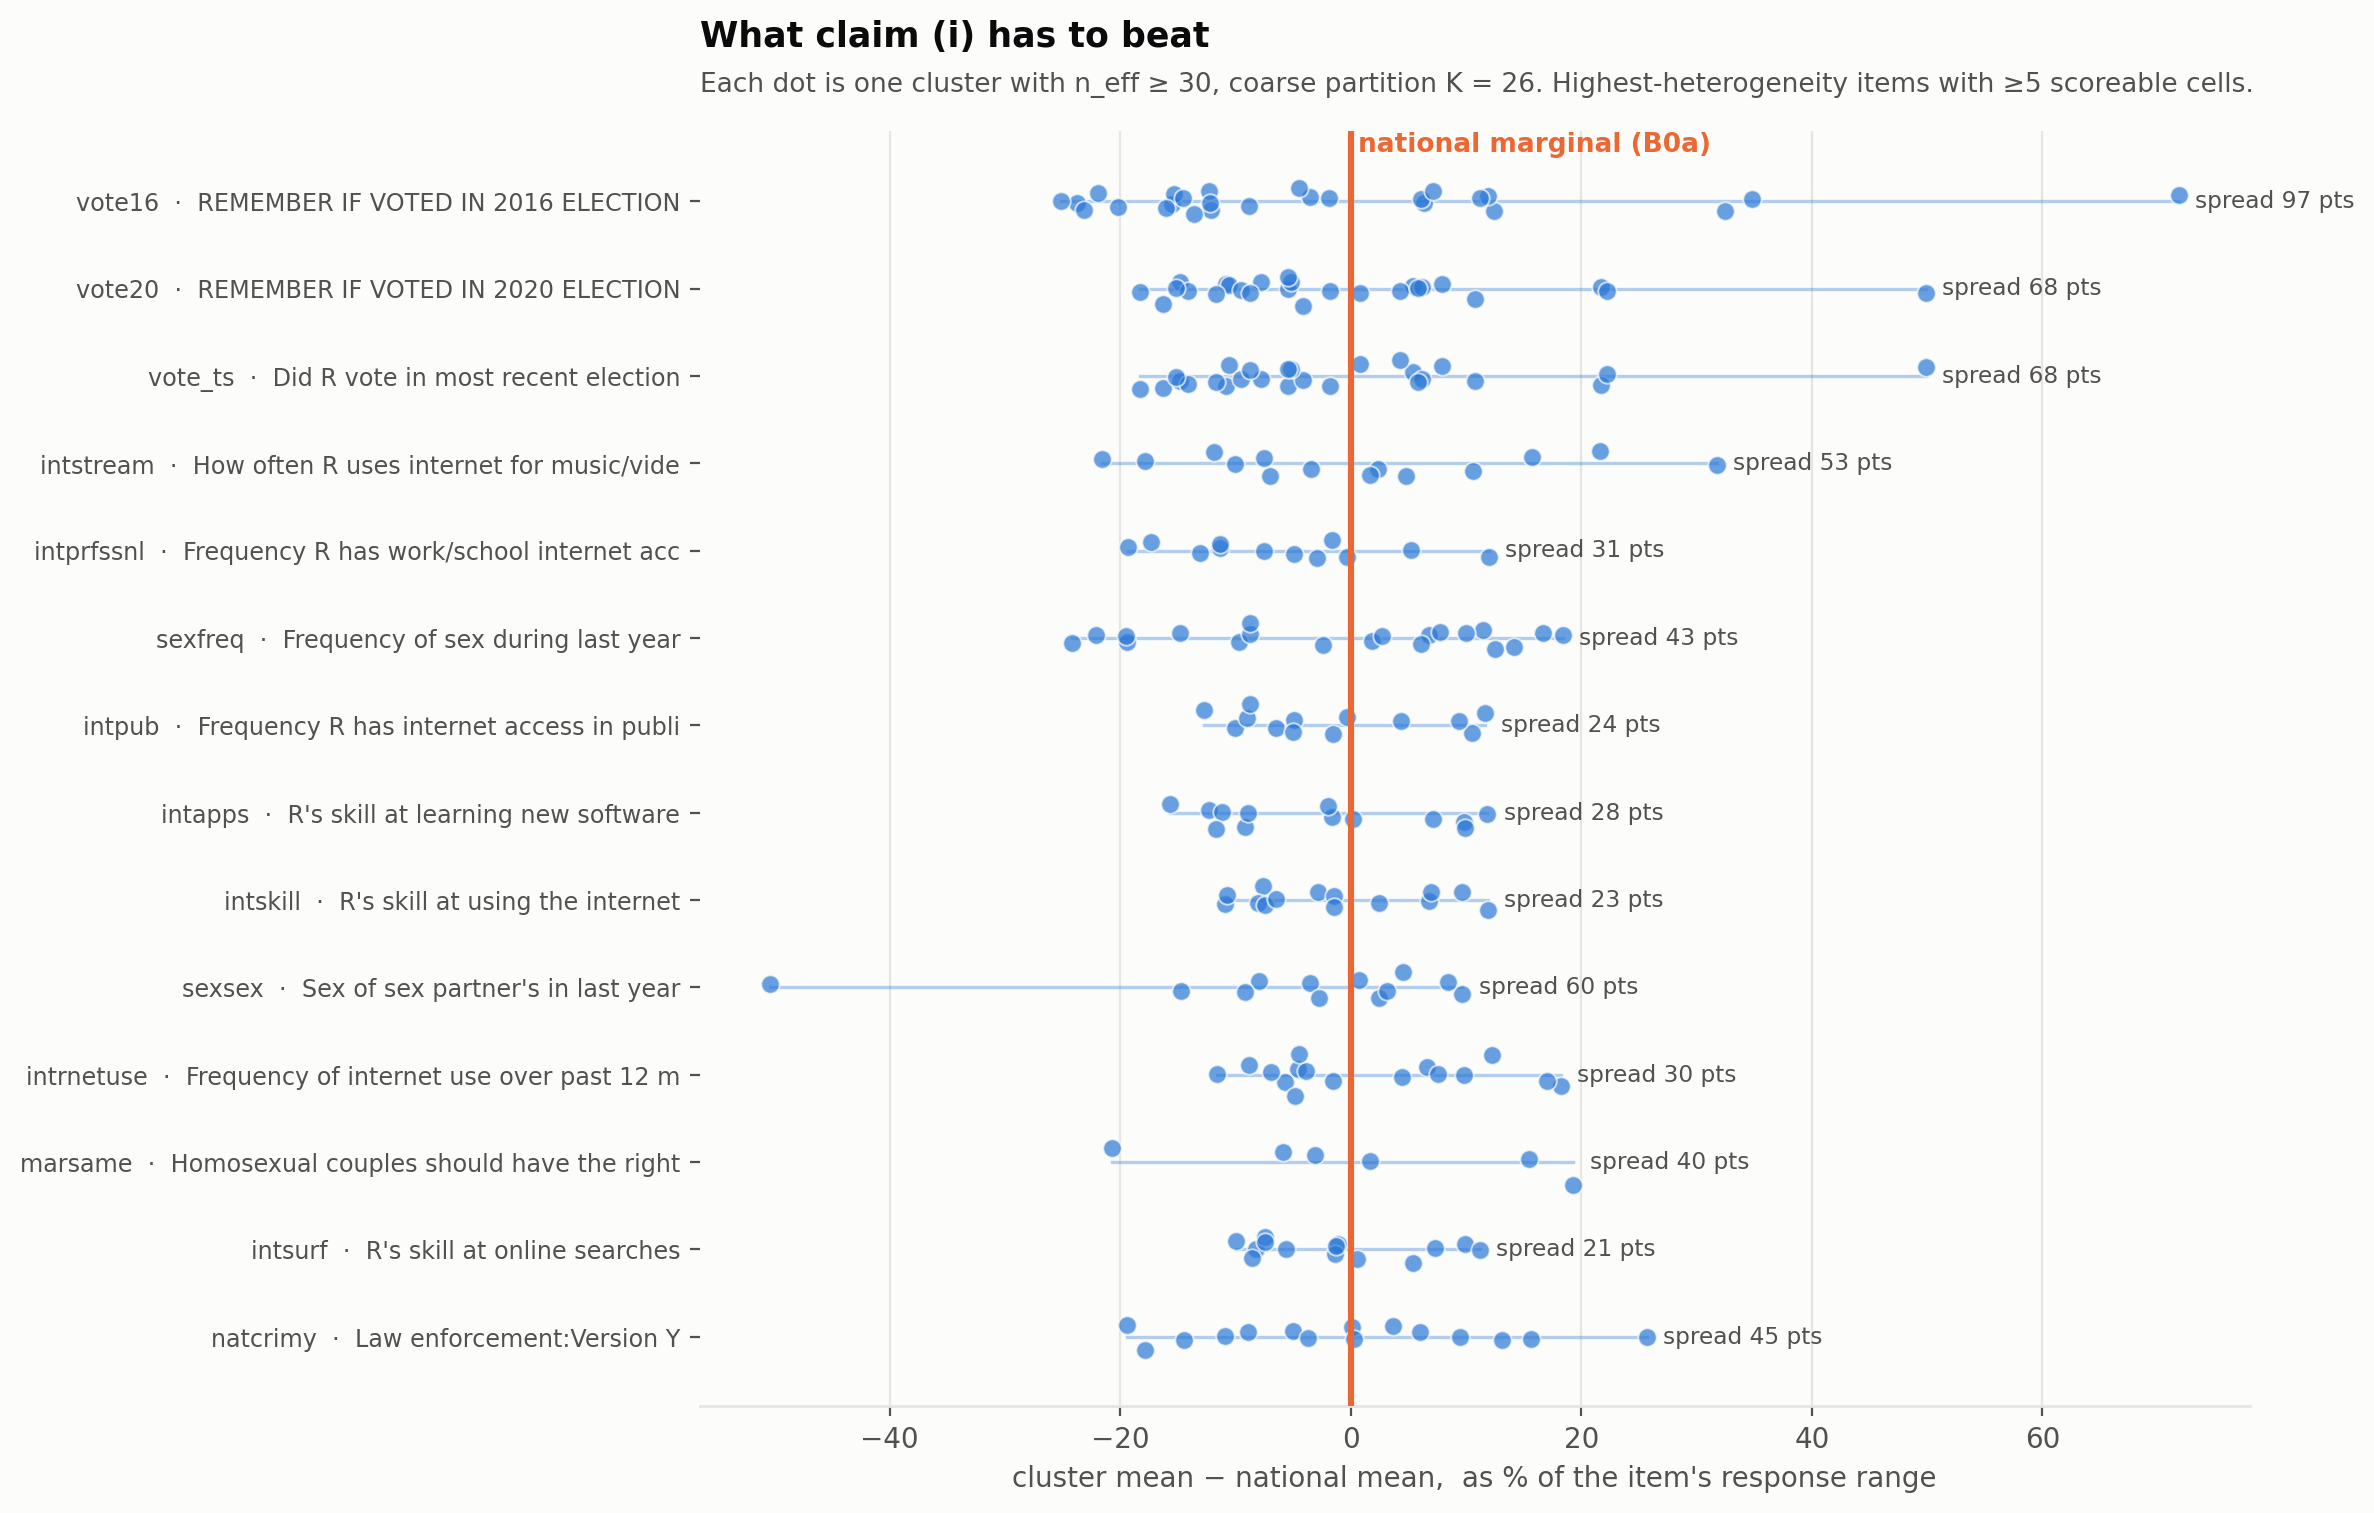

In [13]:
show("fig07_between_cluster_spread.png")

### 3.3 Item supply and the split

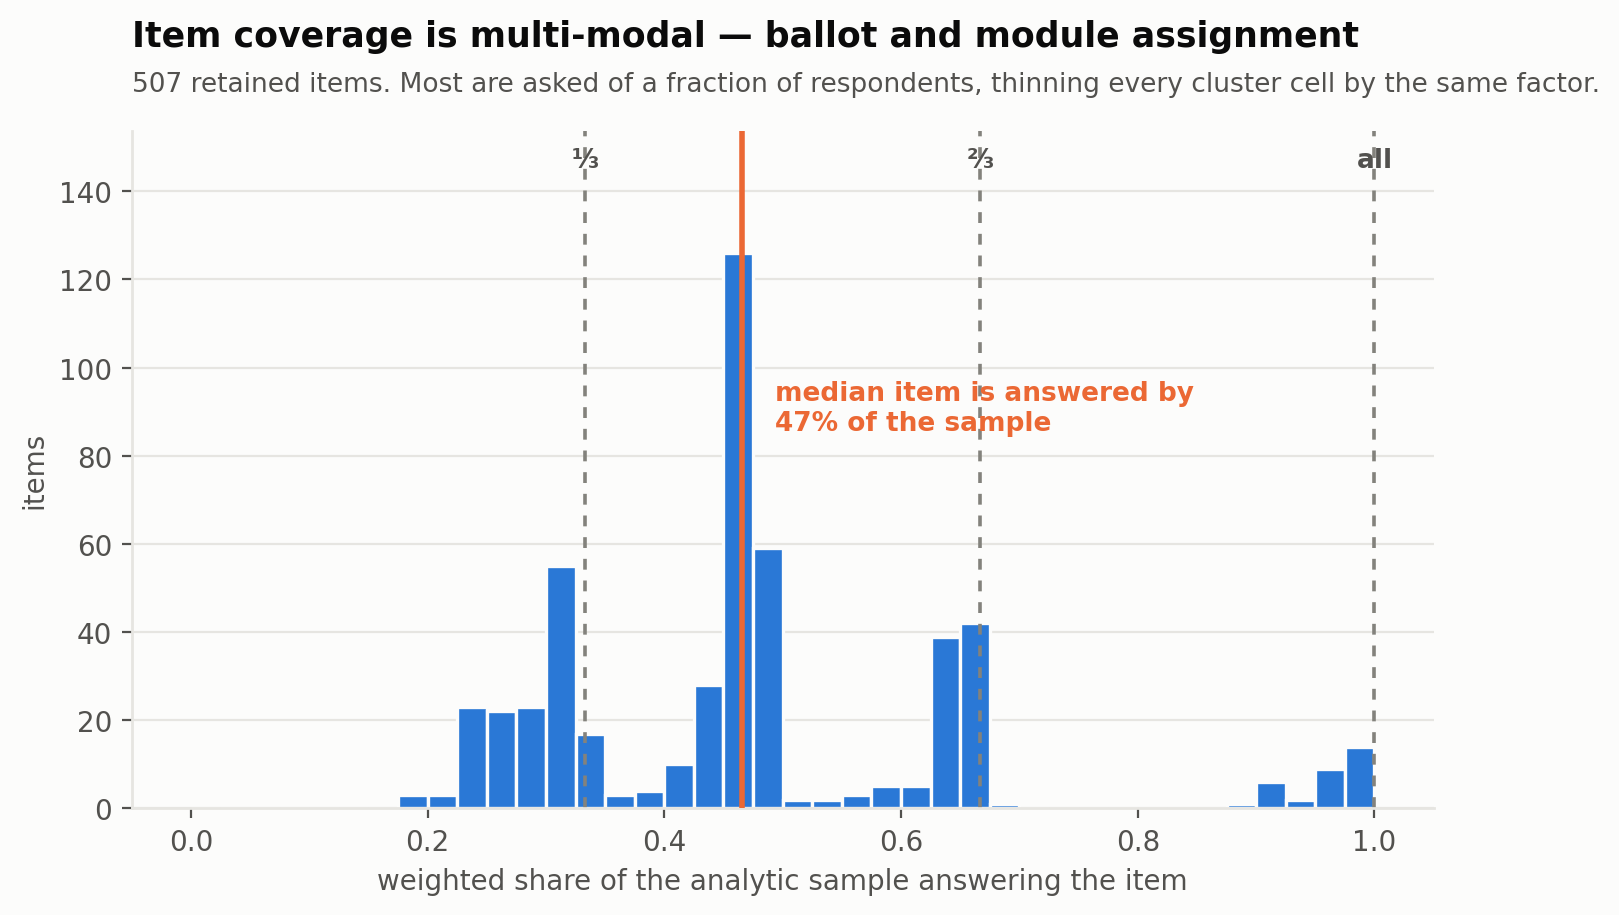

In [14]:
show("fig05_item_coverage.png")

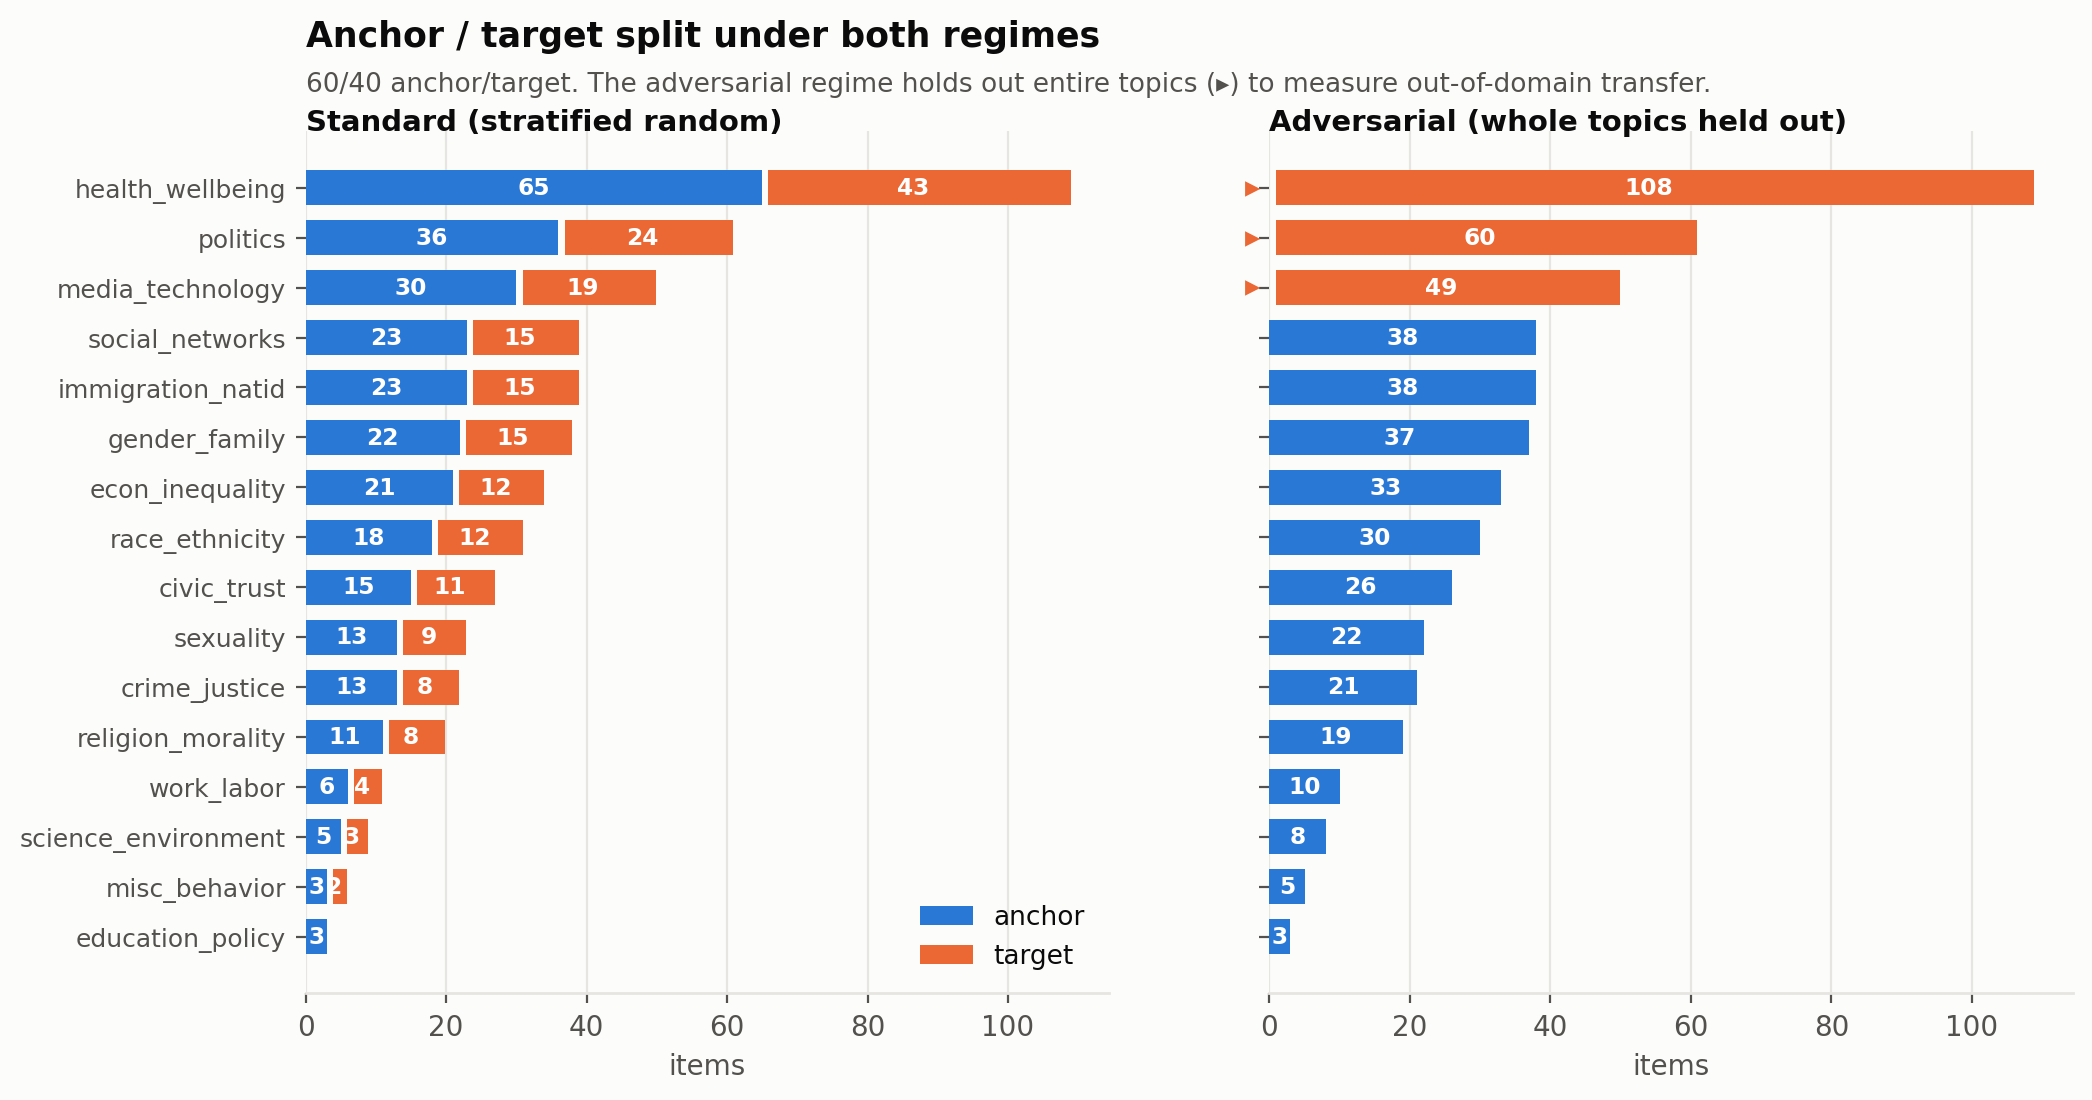

In [15]:
show("fig06_anchor_target_split.png")

### 3.4 Weighting

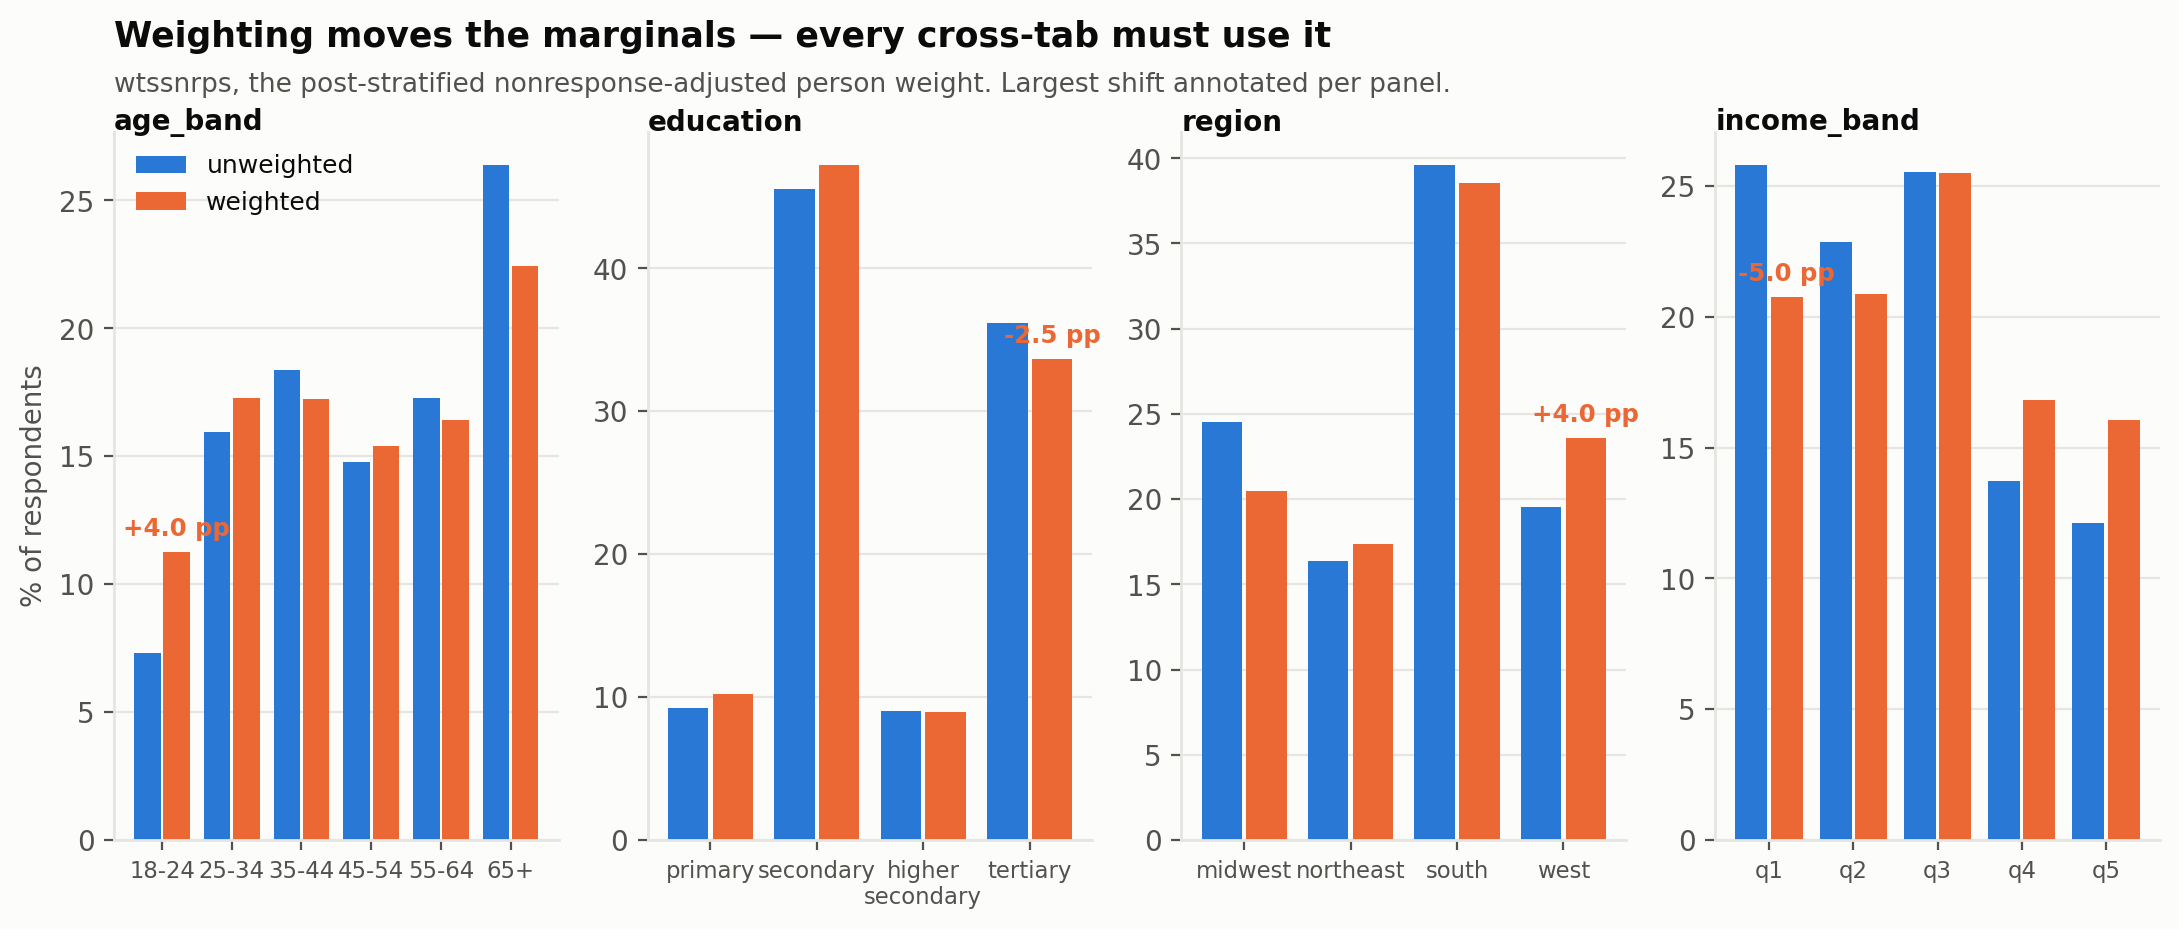

In [16]:
show("fig08_weighting_effect.png")

## 4 · The split, as a table

In [17]:
sm = (split.groupby(["topic"])
      .agg(items=("item_id", "size"),
           anchors=("role_standard", lambda s: (s == "anchor").sum()),
           median_h=("h_icc", "median"),
           max_h=("h_icc", "max"))
      .sort_values("median_h", ascending=False).round(4))
sm

,items,anchors,median_h,max_h
topic,,,,
immigration_natid,38,23,0.1028,0.2026
media_technology,49,30,0.1010,0.2341
religion_morality,19,11,0.0970,0.1596
gender_family,37,22,0.0966,0.2545
politics,60,36,0.0958,0.4851
econ_inequality,33,21,0.0941,0.3299
crime_justice,21,13,0.0907,0.1779
sexuality,22,13,0.0905,0.2450
education_policy,3,3,0.0845,0.1405


In [18]:
# Items available for §1.4 claim (i): held-out targets in the top heterogeneity
# quartile that actually have scoreable cells.
q75 = split.h_icc.quantile(0.75)
cells_main   = cstats[cstats.n_eff >= MIN_NEFF].groupby("item_id").size()
cells_coarse = cstats_c[cstats_c.n_eff >= MIN_NEFF].groupby("item_id").size()

for name, cells, kk in (("main", cells_main, K), ("coarse", cells_coarse, K_C)):
    elig = split[(split.role_standard == "target") & (split.h_icc >= q75)]
    elig = elig.assign(n_cells=elig.item_id.map(cells).fillna(0))
    ok = elig[elig.n_cells >= 5]
    print(f"{name:7s} K={kk:4d}   top-quartile held-out targets with >=5 "
          f"scoreable clusters: {len(ok):3d} of {len(elig)}   "
          f"(spec §1.4 asks for >= 40)")

main    K= 122   top-quartile held-out targets with >=5 scoreable clusters:   0 of 51   (spec §1.4 asks for >= 40)


coarse  K=  26   top-quartile held-out targets with >=5 scoreable clusters:  32 of 51   (spec §1.4 asks for >= 40)


**This is the number that decides whether the study can run as written.**
§1.4 requires ≥ 40 held-out items. Compare the two partitions: the one that
meets the spec's K target and the one that has usable ground truth.

## 5 · Lookups

In [19]:
def cluster(query, n=5):
    hits = [x for x in nodes if x["level"] == 2
            and query.lower() in x["definition_text"].lower()]
    for h in sorted(hits, key=lambda x: -x["n_raw"])[:n]:
        print(f"n={h['n_raw']:4d} n_eff={h['n_eff']:6.1f}  {h['definition_text']}")
        print(f"   id: {h['cluster_id']}")
    print(f"({len(hits)} matches)")

cluster("college graduates, income q4")

n=  33 n_eff=  18.2  either sex, aged 35-44, college graduates, income q4–q5, urban/suburban, the South
   id: gss:south:True:35-44:tertiary:q4,q5:female,male
n=  28 n_eff=  16.0  either sex, aged 55-64, college graduates, income q4–q5, urban/suburban, the South
   id: gss:south:True:55-64:tertiary:q4,q5:female,male
n=  20 n_eff=  12.8  women, aged 35-44, college graduates, income q4–q5, urban/suburban, the Midwest
   id: gss:midwest:True:35-44:tertiary:q4,q5:female
n=  18 n_eff=  12.6  either sex, aged 65+, college graduates, income q4–q5, urban/suburban, the Northeast
   id: gss:northeast:True:65+:tertiary:q4,q5:female,male
n=  17 n_eff=   9.8  men, aged 35-44, college graduates, income q4–q5, urban/suburban, the Midwest
   id: gss:midwest:True:35-44:tertiary:q4,q5:male
(5 matches)


In [20]:
def item(item_id):
    c = codebook[item_id]
    r = split[split.item_id == item_id].iloc[0]
    print(f"{item_id}  —  {c['text']}")
    print(f"  topic {c['topic']} · coverage {c['coverage']:.2f} · "
          f"h_icc {c['heterogeneity']} (raw {c['heterogeneity_raw']})")
    print(f"  role: standard={r.role_standard}  adversarial={r.role_adversarial}")
    pop = pstats[pstats.item_id == item_id].iloc[0]
    for lab, p in zip(c["scale"]["labels"], pop["hist"]):
        print(f"    {100*p:5.1f}%  {lab}")

item("polviews")

polviews  —  Think of self as liberal or conservative
  topic politics · coverage 0.95 · h_icc 0.10196 (raw 0.13543)
  role: standard=anchor  adversarial=target
      3.6%  extremely liberal
     12.8%  liberal
     11.0%  slightly liberal
     37.1%  moderate, middle of the road
     11.8%  slightly conservative
     17.0%  conservative
      6.6%  extremely conservative


In [21]:
def cluster_vs_nation(item_id, min_neff=None, coarse=True):
    src = cstats_c if coarse else cstats
    mn = MIN_NEFF if min_neff is None else min_neff
    d = src[(src.item_id == item_id) & (src.n_eff >= mn)].copy()
    tree = {n["cluster_id"]: n["definition_text"]
            for n in (nodes_c if coarse else nodes)}
    d["cluster"] = d.cluster_id.map(tree)
    pop = pstats[pstats.item_id == item_id].iloc[0]["mean"]
    d["vs_nation"] = (d["mean"] - pop).round(3)
    return d[["cluster", "n_raw", "n_eff", "mean", "sd", "vs_nation"]] \
             .sort_values("vs_nation")

cluster_vs_nation("polviews").head(10)

,cluster,n_raw,n_eff,mean,sd,vs_nation
89,"either sex, aged 18-24, any education level, a...",89,45.322574,3.739638,1.354678,-0.441
84,"women, aged 18-54, any education level, any in...",130,62.467857,3.743020,1.598046,-0.437
98,"either sex, aged 18-34, any education level, a...",113,69.596722,3.762004,1.546953,-0.418
80,"either sex, aged 35-44, any education level, a...",124,64.952824,3.764387,1.348798,-0.416
99,"either sex, aged 35-44, any education level, a...",123,69.148892,3.860802,1.419856,-0.320
86,"either sex, aged 55-64, any education level, a...",97,48.014108,3.891472,1.602727,-0.289
100,"either sex, aged 45-64, any education level, a...",166,101.358631,3.915301,1.639568,-0.265
79,"either sex, aged 18-34, any education level, a...",135,72.944821,3.960519,1.509320,-0.220
85,"men, aged 18-54, any education level, any inco...",88,47.721791,3.989768,1.717546,-0.191
92,"either sex, aged 35-44, less than HS to high s...",84,46.199131,4.002704,1.442672,-0.178


## 6 · What M3 needs next

`cluster_tree.json` + `cluster_stats.parquet` are exactly the inputs the stat
card builder takes. The one contract M3 must enforce that this stage cannot:
a stat card for item Y must exclude Y, its near-duplicates, and every anchor in
Y's cross-fit fold (§3.3 M3). The fold assignment is not yet written here
because it depends on M9's cross-fit plan (`F = 3`).